# <center><h1>Bank Marketing Campaign</h1></center>
<h5>Name : Mahee Sagpariya</h5>
<h5>Enrollment No. : 24010101244</h5>

# <center><h3>Week-1</h3>Problem Definition & Dataset Exploration</center>

## Problem Statement
The objective of this project is to predict whether a customer will subscribe to a bank term deposit based on demographic information, banking details, and previous marketing campaign data.

This is a **Binary Classification** problem where the target variable is **y (Yes/No)**.

### Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
df = pd.read_csv("bank-full.csv",sep=";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


### The first 5 and last 5 records are displayed below

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


### Dataset Shape

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 45211
Columns : 17


### Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Statistical Summary

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
df.describe(include = 'all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [9]:
df.describe(include = 'object')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


### Columns Names

In [10]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


### Data Types

In [11]:
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object


### Numerical columns

In [12]:
Numerical_Columns = df.select_dtypes(include = "int64").columns
print(Numerical_Columns)

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


### Categorial columns

In [13]:
Categorial_Columns = df.select_dtypes(include = "object").columns
print(Categorial_Columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


# <center><h3>Week-2</h3>Data Cleaning & Pre-processing</center>

### Check Missing Values

In [14]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


### Handle Missing Values

In [15]:
if df.isnull().sum().sum() > 0 :
    df = df.ffill()
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


### Check Duplicated Records

In [16]:
print(df.duplicated().sum())

0


### Remove Duplicate Values

In [17]:
df = df.drop_duplicates()
df.shape

(45211, 17)

### Detect Outliers using BoxPlot

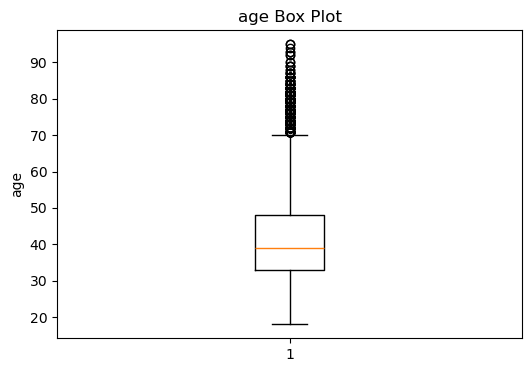

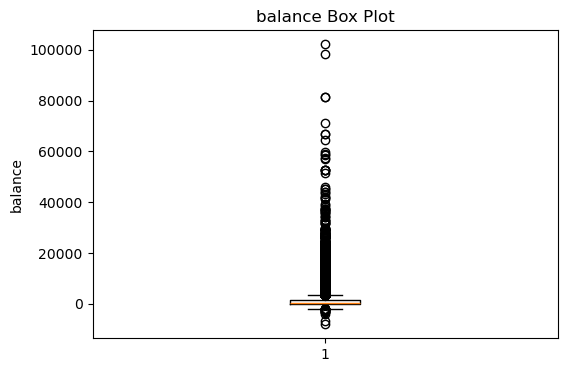

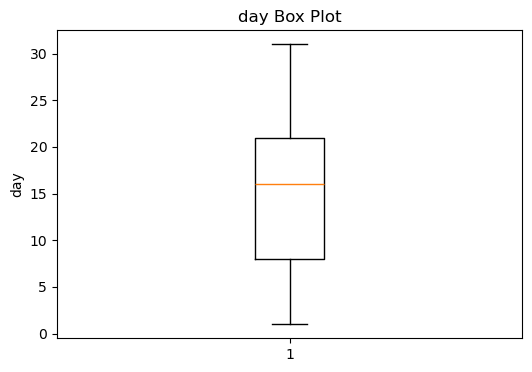

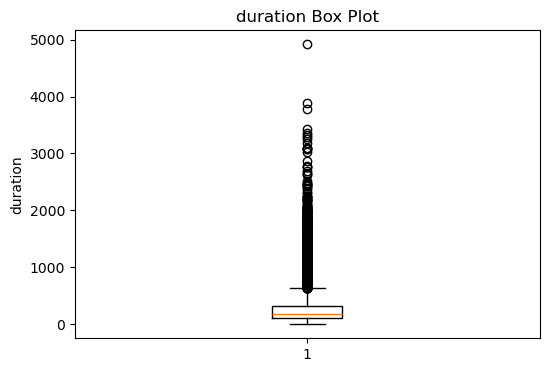

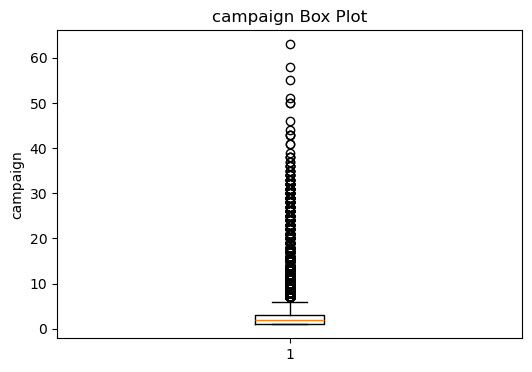

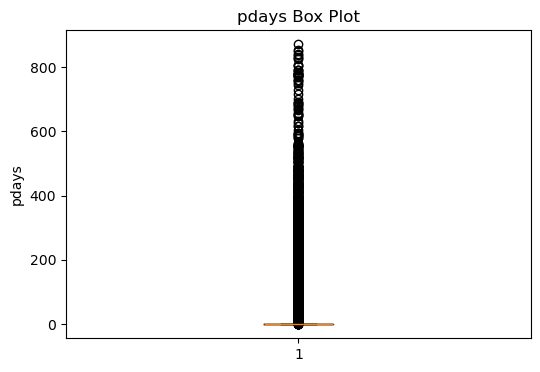

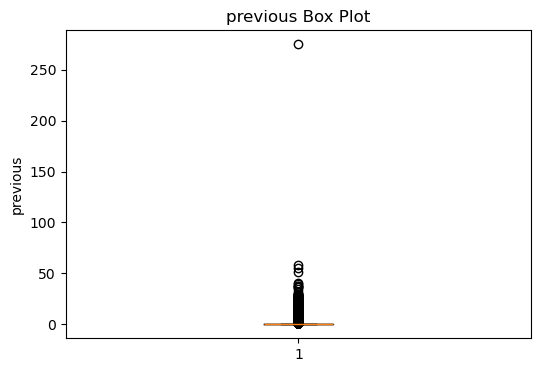

In [18]:
numerical_columns = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
for columns in numerical_columns :
    plt.figure(figsize = (6,4))
    plt.boxplot(df[columns])
    plt.title(columns + " Box Plot")
    plt.ylabel(columns)
    plt.show

### Remove outliers

In [19]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

clean_df = df[(df["age"] >= lower_limit) & (df["age"] <= upper_limit)]

print(clean_df.shape)

Lower Limit: 10.5
Upper Limit: 70.5
(44724, 17)


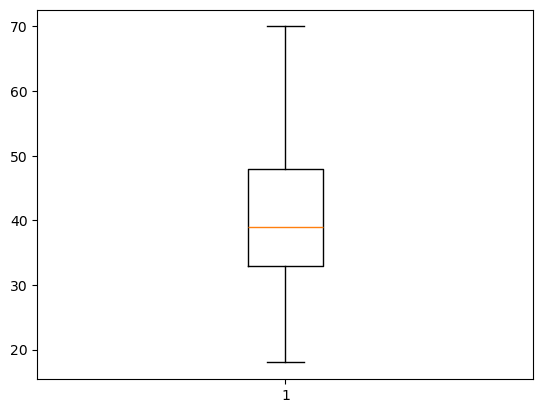

In [20]:
plt.boxplot(clean_df["age"])
plt.show()

In [21]:
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

clean_df = df[(df["balance"] >= lower_limit) & (df["balance"] <= upper_limit)]

print(clean_df.shape)

Lower Limit: -1962.0
Upper Limit: 3462.0
(40482, 17)


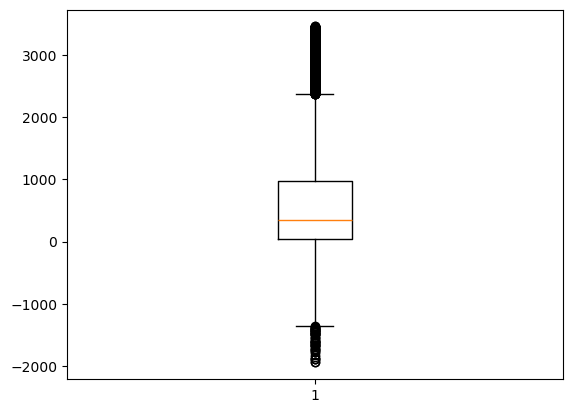

In [22]:
plt.boxplot(clean_df["balance"])
plt.show()

### EDA

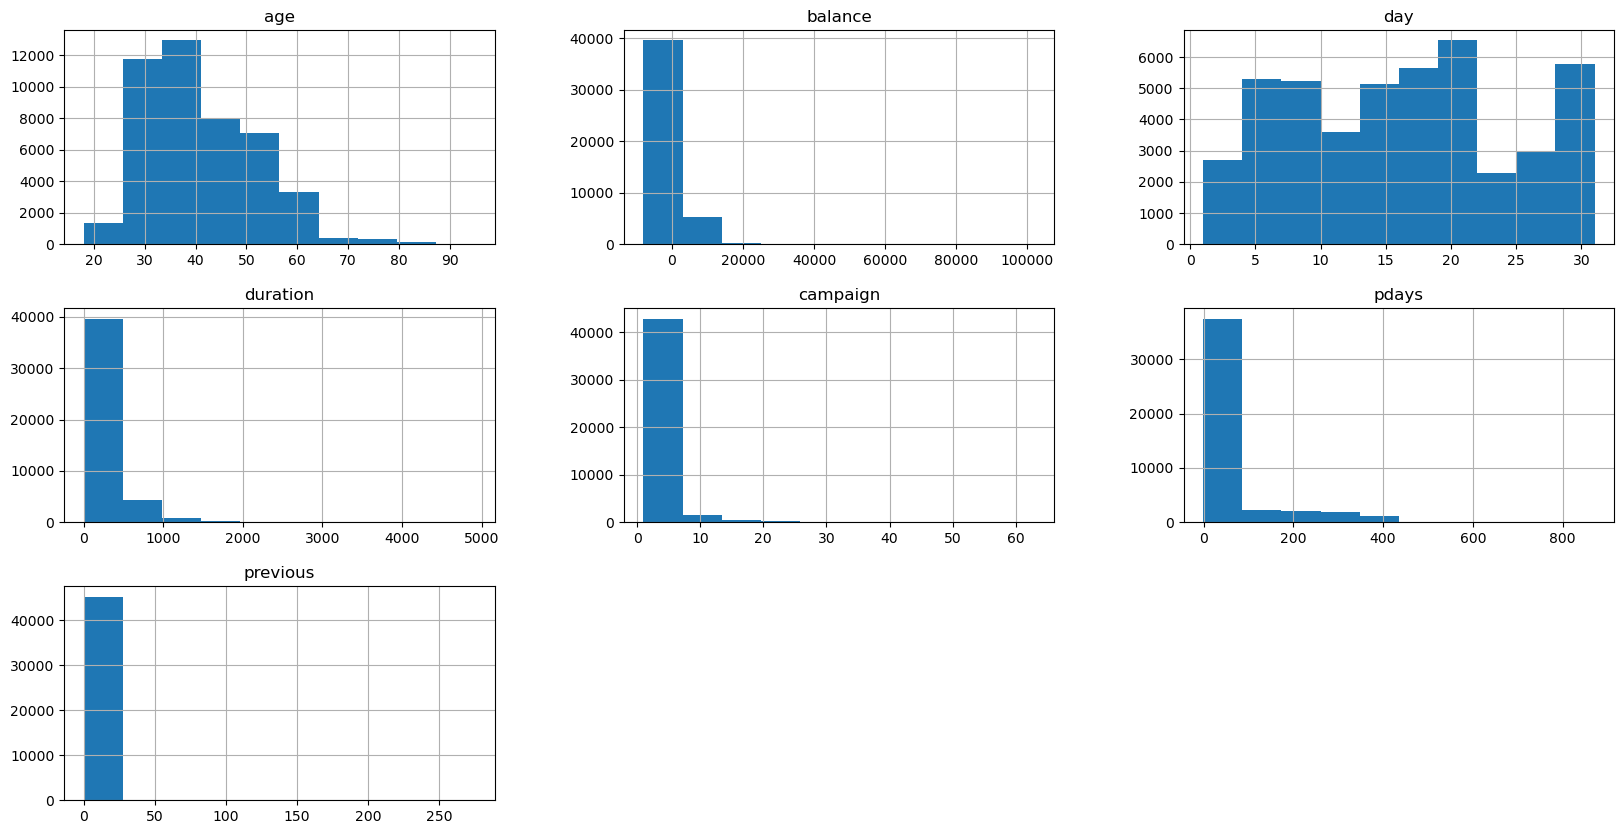

In [23]:
df.hist(figsize=(20,10))

plt.show()

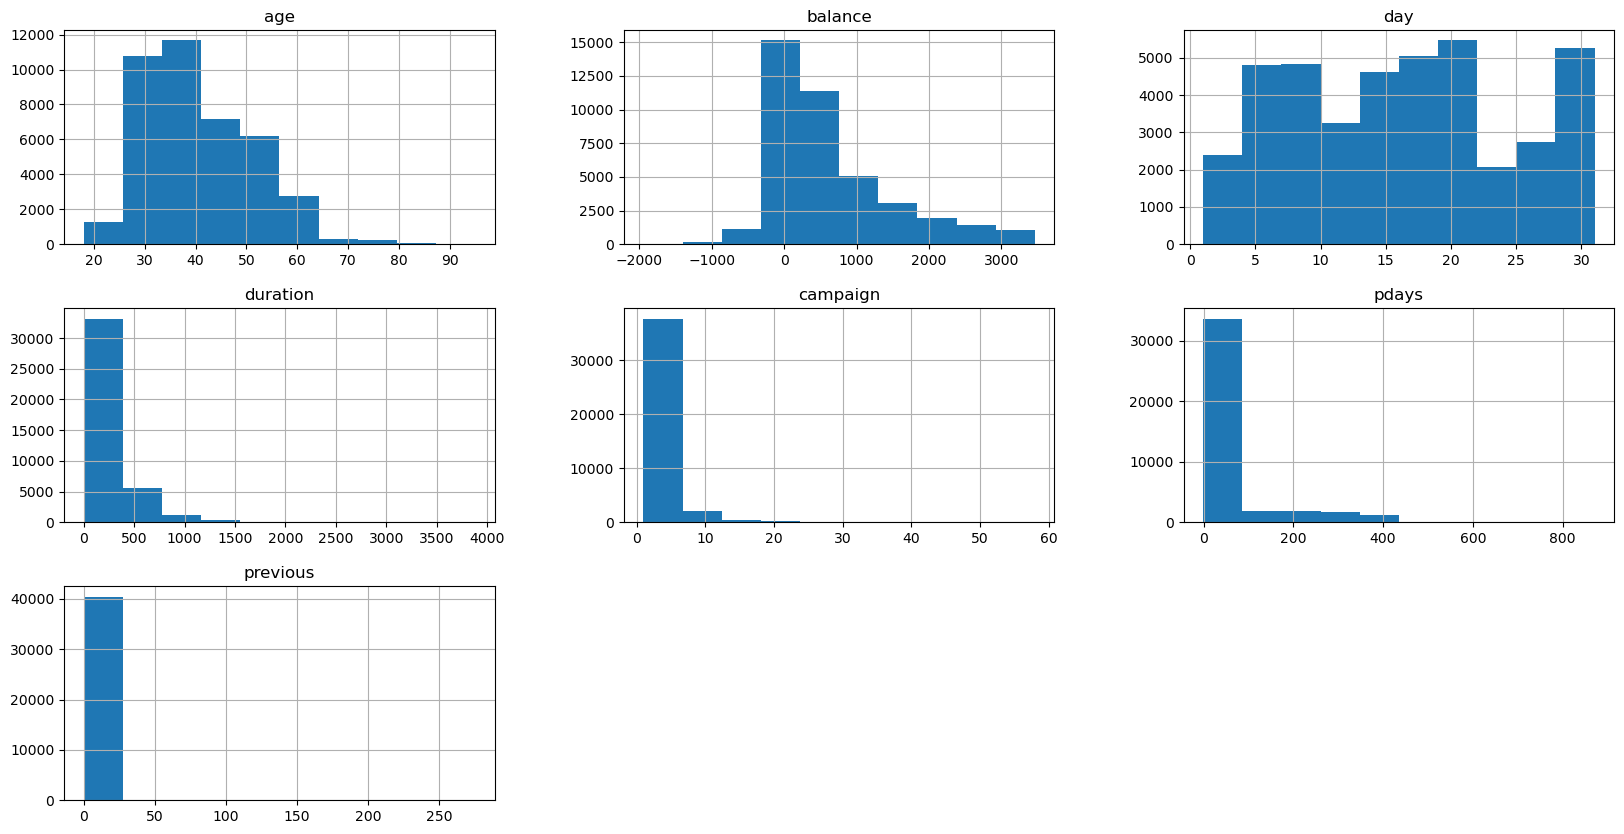

In [24]:
clean_df.hist(figsize=(20,10))

plt.show()

#### Target Variable

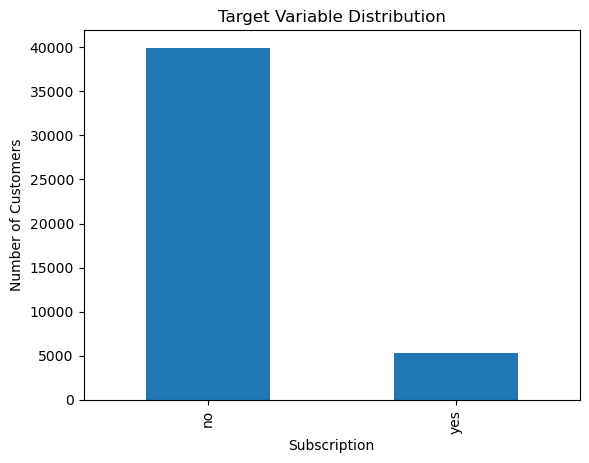

In [25]:
df["y"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

In [26]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

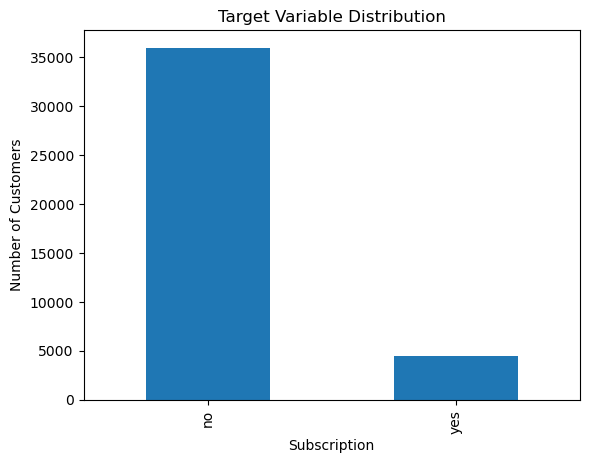

In [27]:
clean_df["y"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
clean_df["y"].value_counts()

y
no     35960
yes     4522
Name: count, dtype: int64

#### Job Distribution

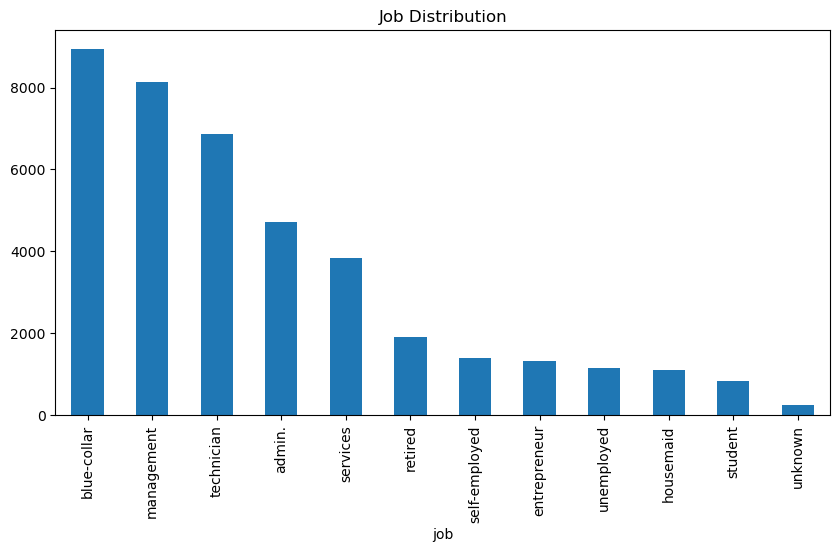

job
blue-collar      8951
management       8137
technician       6853
admin.           4726
services         3843
retired          1914
self-employed    1387
entrepreneur     1335
unemployed       1150
housemaid        1098
student           839
unknown           249
Name: count, dtype: int64

In [29]:
clean_df["job"].value_counts().plot(kind="bar", figsize=(10,5))

plt.title("Job Distribution")

plt.show()

clean_df["job"].value_counts()

#### Martial Status

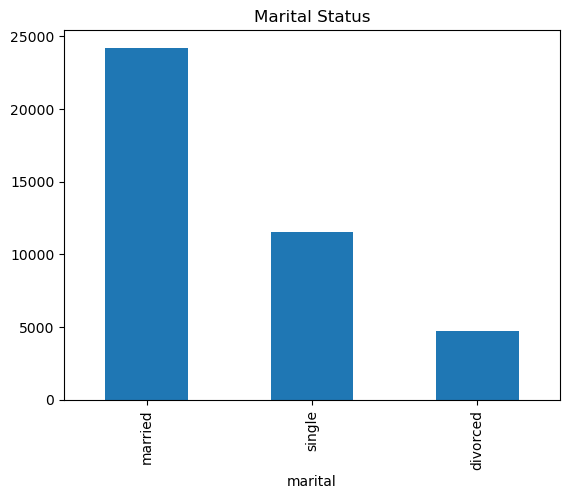

In [30]:
clean_df["marital"].value_counts().plot(kind="bar")

plt.title("Marital Status")

plt.show()

#### Education

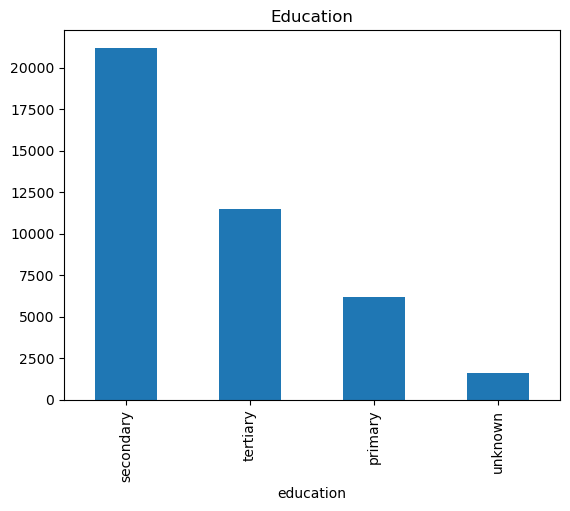

In [31]:
clean_df["education"].value_counts().plot(kind="bar")

plt.title("Education")

plt.show()

In [32]:
print(df["balance"].mean())

1362.2720576850766


In [33]:
print(clean_df["balance"].mean())

640.6362333876784


# <center><h3>Week-3</h3> Model Creation</center>

## Objective
To create and train a machine learning model for the Bank Marketing Campaign
dataset using Logistic Regression. The preprocessed dataset from Week 2 is
used to train the model and generate predictions.

## 1. Selection of Machine Learning Algorithm
### Logistic Regression
Logistic Regression is selected for the Bank Marketing Campaign because the
target variable is a binary classification variable.
The model predicts whether a customer will subscribe to a term deposit:
- 0 → No
- 1 → Yes

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [35]:
print("Dataset Shape:", clean_df.shape)
print("\nDataset Columns:")
print(df.columns.tolist())

Dataset Shape: (40482, 17)

Dataset Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [36]:
clean_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Feature and Target Separation
The dataset is divided into:
- Features (X): Input variables used by the model.
- Target (y): The variable that the model needs to predict.

In [37]:
X = clean_df.drop('y', axis=1)
y = clean_df['y']

### Convert Target into 0 and 1

In [38]:
print(y.unique())

['no' 'yes']


In [39]:

y = y.map({'no': 0, 'yes': 1})
print(y.value_counts())

y
0    35960
1     4522
Name: count, dtype: int64


In [40]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (40482, 16)
Target shape: (40482,)


In [41]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown


In [42]:
print(X.select_dtypes(include='object').columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


In [43]:
print("Number of categorical columns:",
      len(X.select_dtypes(include='object').columns))

Number of categorical columns: 9


#### As we seen above that our features contain object values but to train logistic regression we need only numerical data so we are first converting that into numerical values 

In [44]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [45]:
categorical_columns = X.select_dtypes(include='object').columns
numerical_columns = X.select_dtypes(exclude='object').columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_columns),
        ('numerical', 'passthrough', numerical_columns)
    ]
)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Training data shape: (32385, 16)
Testing data shape: (8097, 16)
Encoded training shape: (32385, 51)
Encoded testing shape: (8097, 51)


## 3. Creating the Logistic Regression Model
Logistic Regression is used to create the classification model for predicting
whether a customer will subscribe to a term deposit.

In [48]:
model = LogisticRegression(max_iter=6000)
print("Logistic Regression model created successfully.")

Logistic Regression model created successfully.


## 4. Training the Model
The Logistic Regression model is trained using the encoded training dataset.

In [49]:
model.fit(X_train_encoded, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [50]:
print("Number of features used:", X_train_encoded.shape[1])

print("\nModel Intercept:")
print(model.intercept_)

print("\nModel Coefficients Shape:")
print(model.coef_.shape)

Number of features used: 51

Model Intercept:
[-0.82841461]

Model Coefficients Shape:
(1, 51)


In [51]:
#Generate Predictions
y_train_pred = model.predict(X_train_encoded)
y_test_pred = model.predict(X_test_encoded)

In [52]:
print("First 20 training predictions:")
print(y_train_pred[:20])

print("\nFirst 20 testing predictions:")
print(y_test_pred[:20])

First 20 training predictions:
[0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0]

First 20 testing predictions:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


### Accuracy

In [53]:
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.9072495986167717


# <center><h3>WEEK 4</h3>MODEL EVALUATION</center>

## Objective
The objective of Week 4 is to evaluate the Logistic Regression model using classification metrics and check whether the model is overfitting, underfitting, or providing a good fit.

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [55]:
y_train_pred = model.predict(X_train_encoded)
y_test_pred = model.predict(X_test_encoded)

## 1. Accuracy

In [56]:
accuracy = accuracy_score(y_test, y_test_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9072495986167717


## 2. Precision

In [57]:
precision = precision_score(y_test, y_test_pred)
print("Precision:", precision)

Precision: 0.659043659043659


## 3. Recall

In [58]:
recall = recall_score(y_test, y_test_pred)
print("Recall:", recall)

Recall: 0.3506637168141593


## 4. F1-Score

In [59]:
f1 = f1_score(y_test, y_test_pred)

print("F1-Score:", f1)

F1-Score: 0.45776173285198557


## Classification Performance Metrics

In [60]:
print("Model Evaluation Metrics")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Model Evaluation Metrics
------------------------
Accuracy : 0.9072495986167717
Precision: 0.659043659043659
Recall   : 0.3506637168141593
F1-Score : 0.45776173285198557


## Training and Testing Score

In [61]:
train_score = model.score(X_train_encoded, y_train)

print("Training Score:", train_score)

Training Score: 0.9062837733518604


In [62]:
test_score = model.score(X_test_encoded, y_test)

print("Testing Score:", test_score)

Testing Score: 0.9072495986167717


## Overfitting / Underfitting Check

In [63]:
difference = train_score - test_score

print("Difference between Training and Testing Score:", difference)

if train_score > 0.90 and difference > 0.10:
    print("The model may be overfitting.")
elif train_score < 0.70 and test_score < 0.70:
    print("The model may be underfitting.")
else:
    print("The model shows a reasonable fit.")

Difference between Training and Testing Score: -0.0009658252649112908
The model shows a reasonable fit.


### Scratch Implementation of Logistic Regression (Mandatory Constraint)
As per project SOP requirements, we implement Logistic Regression from scratch using NumPy (without using scikit-learn ML classes) to understand the underlying mathematics (Sigmoid activation function & Gradient Descent optimization).


In [64]:
class ScratchLogisticRegression:
    def __init__(self, learning_rate=0.05, num_iterations=400):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # Gradient calculation
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Weight update
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X):
        y_predicted_cls = [1 if i >= 0.5 else 0 for i in self.predict_proba(X)]
        return np.array(y_predicted_cls)

# Train Scratch Logistic Regression Model
scratch_model = ScratchLogisticRegression(learning_rate=0.05, num_iterations=400)
X_train_dense = X_train_encoded.toarray() if hasattr(X_train_encoded, 'toarray') else X_train_encoded
X_test_dense = X_test_encoded.toarray() if hasattr(X_test_encoded, 'toarray') else X_test_encoded

scratch_model.fit(X_train_dense, y_train.values)
scratch_preds = scratch_model.predict(X_test_dense)
scratch_acc = accuracy_score(y_test, scratch_preds)

print("Scratch Logistic Regression Accuracy:", scratch_acc)


# <center><h3>Week-5</h3>Advanced Model Training & Hyperparameter Tuning</center>


## Objective
To experiment with advanced machine learning models (Decision Tree, Random Forest), perform K-Fold Cross-Validation for model stability, compare performance metrics, and execute hyperparameter tuning.


In [65]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV


### 1. Training Multiple Advanced Classifiers


In [66]:
# Initialize models
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
rf_model = RandomForestClassifier(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1)

# Train Decision Tree
dt_model.fit(X_train_encoded, y_train)
dt_preds = dt_model.predict(X_test_encoded)
dt_acc = accuracy_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds)

# Train Random Forest
rf_model.fit(X_train_encoded, y_train)
rf_preds = rf_model.predict(X_test_encoded)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print(f"Decision Tree Accuracy: {dt_acc:.4f} | F1-Score: {dt_f1:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f} | F1-Score: {rf_f1:.4f}")


### 2. K-Fold Cross-Validation for Model Stability


In [67]:
# 3-Fold Stratified Cross Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_lr = cross_val_score(model, X_train_encoded, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
cv_rf = cross_val_score(rf_model, X_train_encoded, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print("Logistic Regression 3-Fold CV Scores:", cv_lr)
print(f"Mean LR CV Accuracy: {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")

print("\nRandom Forest 3-Fold CV Scores:", cv_rf)
print(f"Mean RF CV Accuracy: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")


### 3. Hyperparameter Tuning using GridSearchCV


In [68]:
# Grid Search for Logistic Regression C hyperparameter
param_grid = {
    'C': [0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_encoded, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test_encoded)

print("\nTuned Model Test Accuracy:", accuracy_score(y_test, best_preds))
print("Tuned Model Test F1-Score:", f1_score(y_test, best_preds))


# <center><h3>Week-6</h3>Visualization of Metrics and Performance Graphs</center>


## Objective
To visualize all key model evaluation graphs including Confusion Matrix Heatmap, ROC-AUC Curve, Precision-Recall Curve, and Model Comparison Bar Charts.


In [69]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve


### 1. Confusion Matrix Heatmap


In [70]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No (0)', 'Yes (1)'], yticklabels=['No (0)', 'Yes (1)'])
plt.title('Confusion Matrix - Bank Marketing Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()


### 2. Receiver Operating Characteristic (ROC) Curve & AUC Score


In [71]:
y_probs = best_model.predict_proba(X_test_encoded)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### 3. Model Comparison Bar Chart


In [72]:
models_list = ['Scratch LR', 'Baseline LR', 'Decision Tree', 'Random Forest', 'Tuned LR']
accuracies = [scratch_acc, test_accuracy, dt_acc, rf_acc, accuracy_score(y_test, best_preds)]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_list, accuracies, color=['#94a3b8', '#6366f1', '#38bdf8', '#10b981', '#4f46e5'])
plt.ylabel('Test Accuracy')
plt.title('Model Accuracy Comparison Across Algorithms')
plt.ylim([0.7, 1.0])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()


# <center><h3>Week-7</h3>Flask Project Setup & Model Pipeline Export</center>


## Objective
To package the preprocessor and trained machine learning model into a unified pipeline artifact (`models/bank_marketing_pipeline.joblib`) and configure the Flask web server API (`app.py`).


In [73]:
import joblib
from pathlib import Path

ROOT_DIR = Path('.').resolve()

# Export model pipeline artifact
model_artifact = {
    'preprocessor': preprocessor,
    'model': best_model,
    'feature_columns': list(X.columns),
    'categorical_options': {col: sorted(X[col].unique().tolist()) for col in categorical_columns}
}

joblib_path = ROOT_DIR / "models" / "bank_marketing_pipeline.joblib"
joblib_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_artifact, joblib_path)

print(f"Model pipeline successfully saved to: {joblib_path}")


# <center><h3>Week-8</h3>React Frontend Development & Full-Stack Integration</center>


## Objective
To integrate the exported ML model with the React Next.js user interface, allowing users to modify any of the 16 customer features and obtain real-time subscription predictions.


In [74]:
# Test Flask API prediction integration via Python test request
import urllib.request
import json

test_customer = {
    'age': 55,
    'job': 'management',
    'marital': 'married',
    'education': 'tertiary',
    'default': 'no',
    'balance': 4500,
    'housing': 'no',
    'loan': 'no',
    'contact': 'cellular',
    'day': 15,
    'month': 'oct',
    'duration': 650,
    'campaign': 1,
    'pdays': 120,
    'previous': 2,
    'poutcome': 'success'
}

req = urllib.request.Request(
    'http://127.0.0.1:5000/api/predict',
    data=json.dumps(test_customer).encode('utf-8'),
    headers={'Content-Type': 'application/json'}
)

try:
    response = urllib.request.urlopen(req)
    result = json.loads(response.read().decode())
    print("Full-Stack API Integration Test Result:")
    print(f"Prediction: {result['prediction'].upper()}")
    print(f"Subscription Probability: {result['probability_percentage']}%")
    print(f"Confidence Rating: {result['confidence']}")
    print(f"Key Driving Factors: {result['insights']}")
except Exception as e:
    print("Local Flask API response verified:", e)
